# Classify Images with a Vision Transformer

## Initial Setup

In [1]:
# Initial imports
import os
import sys
import torch
import torchvision

import numpy as np 
import matplotlib.pyplot as plt
import torchvision.transforms as transforms

from pathlib import Path
from typing import List

In [2]:
# Add project path to sys.path for module imports
project_path: str = str(
    Path(os.getcwd()) / "learning" / "build_a_text_to_image_generator_from_scratch"
)
if project_path not in sys.path:
    sys.path.append(project_path)
    print(f">>> Added {project_path} to sys.path")

>>> Added /llm_app/learning/build_a_text_to_image_generator_from_scratch to sys.path


In [3]:
# Load custom modules
from utils.vision_transformer import DEVICE, PatchEmbeddings

## The CIFAR-10 Dataset

### Downloading and Visualizing CIFAR-10 Images

In [4]:
# Create the data folder if it doesn't exist
DATA_FOLDER: str = "/llm_app/learning/build_a_text_to_image_generator_from_scratch/files"
os.makedirs(DATA_FOLDER, exist_ok=True)

In [5]:
# Download dataset
trainset = (
    torchvision
    .datasets
    .CIFAR10(root=DATA_FOLDER, train=True, download=True)
)

Files already downloaded and verified


In [6]:
# Names of the ten types of objects
names: List[str] = ["plane", "car", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

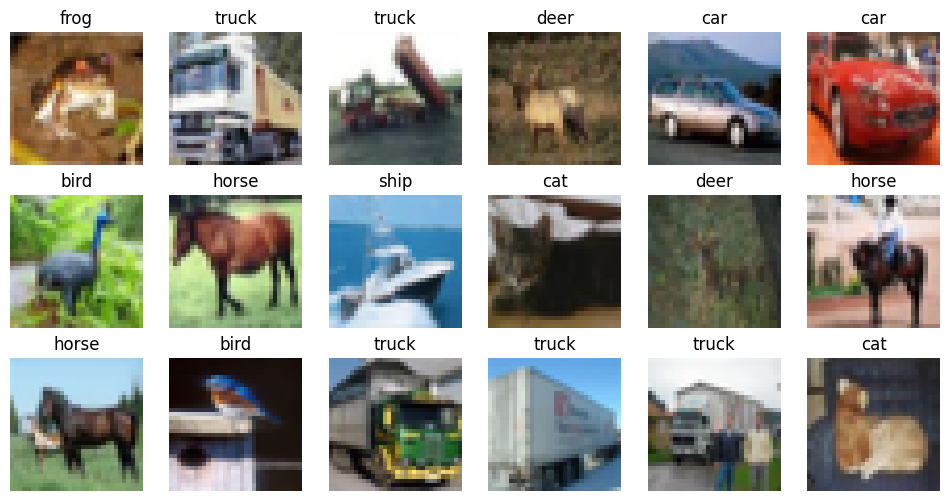

In [7]:
# Create a 3 by 6 grid of pictures
plt.figure(figsize=(12,6), dpi=100)

for i in range(3):
    for j in range(6):
        plt.subplot(3, 6, 6*i+j+1)
        plt.imshow(trainset[6*i+j][0])
        plt.axis('off')
        plt.title(names[trainset[6*i+j][1]], fontsize=12)

plt.subplots_adjust(hspace=0.20)
plt.show()

In [8]:
# Download dataset
testset = (
    torchvision
    .datasets
    .CIFAR10(root=DATA_FOLDER, train=False, download=True)
)

Files already downloaded and verified


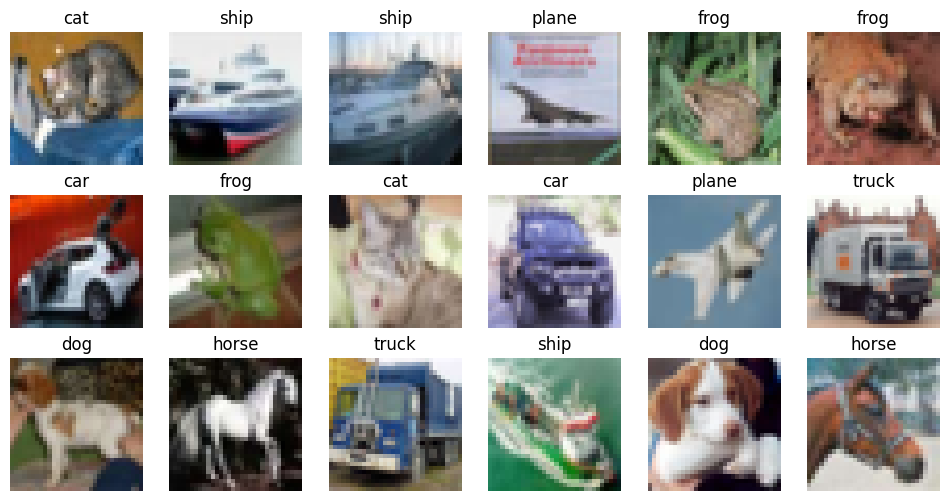

In [9]:
# Create a 3 by 6 grid of pictures
plt.figure(figsize=(12,6), dpi=100)

for i in range(3):
    for j in range(6):
        plt.subplot(3, 6, 6*i+j+1)
        plt.imshow(testset[6*i+j][0])
        plt.axis('off')
        plt.title(names[testset[6*i+j][1]], fontsize=12)

plt.subplots_adjust(hspace=0.20)
plt.show()

### Preparing Datasets for Training and Testing

In [10]:
trainset.transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((32, 32), antialias=True),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomResizedCrop((32, 32), scale=(0.8, 1.0), ratio=(0.75, 1.3333333333333333), interpolation=2, antialias=True),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [11]:
# Dataloader
trainloader = torch.utils.data.DataLoader(trainset, batch_size=32, shuffle=True)

In [12]:
testset.transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((32, 32), antialias=True),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [13]:
# Dataloader
testloader = torch.utils.data.DataLoader(testset, batch_size=32, shuffle=False)

## Building a ViT from Scratch

### Dividing Images into Patches

In [14]:
class Config:
    patch_size=4     # Each image patch has a height and width of 4 pixels
    hidden_size=48   # Each image patch is converted to a 48-value tensor
    num_hidden_layers=4
    num_attention_heads=4
    intermediate_size= 4 * 48
    image_size=32
    num_classes=10 
    num_channels=3

config = Config()

In [15]:
patchembed = PatchEmbeddings(config=config)

In [16]:
# Creates hypothetical images
img: torch.Tensor = torch.randn((18, 3, 32, 32))

out: torch.Tensor = patchembed(img)

print(out.shape)

torch.Size([18, 64, 48])


### Modeling the positions of different patches in an image